# Predict Tommy Award Winners for Other NBA Teams

This notebook trains the same Random Forest model as `random_forest_classifier.ipynb` (on Celtics games), then uses it to predict the per-game "Tommy Award" winner for another NBA team. Defaults to the **New York Knicks**; change `TARGET_TEAM_NAME` to try any other team.

The pipeline:
1. Trains the Random Forest on Celtics player-game data (Optuna-tuned).
2. Pulls the target team's schedule + box scores (traditional, hustle, advanced) from `nba_api`.
3. Reconstructs the exact engineered features used in training (per-minute stats, hustle proxy, per-game ranks, etc.).
4. Assigns each game's Tommy Award to the player with the highest predicted probability.

In [1]:

from pathlib import Path
import random

import numpy as np
import pandas as pd

SEED = 58
random.seed(SEED)
np.random.seed(SEED)

csv_path = Path("Tommy_Award_Player_Game_Table_hustle.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find dataset at: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns from {csv_path.name}")
df.head()

Loaded 8,530 rows and 60 columns from Tommy_Award_Player_Game_Table_hustle.csv


,gameId,teamId,teamCity,teamName,teamTricode,teamSlug,personId,firstName,familyName,nameI,...,assists_rank,steals_rank,blocks_rank,plusMinusPoints_rank,minutes_decimal_rank,deflections,deflections_missing,charges_drawn,charges_drawn_missing,usage_rate
0,21600006,1610612738,Boston,Celtics,BOS,celtics,203109,Jae,Crowder,J. Crowder,...,7.0,2.0,4.0,4.0,3.0,4.0,0,0.0,0,0.00227
1,21600006,1610612738,Boston,Celtics,BOS,celtics,101161,Amir,Johnson,A. Johnson,...,7.0,5.0,5.0,3.0,6.0,3.0,0,0.0,0,0.00185
2,21600006,1610612738,Boston,Celtics,BOS,celtics,201143,Al,Horford,A. Horford,...,2.0,8.0,1.0,2.0,5.0,1.0,0,0.0,0,0.00145
3,21600006,1610612738,Boston,Celtics,BOS,celtics,202340,Avery,Bradley,A. Bradley,...,2.0,5.0,5.0,4.0,1.0,4.0,0,0.0,0,0.00222
4,21600006,1610612738,Boston,Celtics,BOS,celtics,202738,Isaiah,Thomas,I. Thomas,...,1.0,2.0,5.0,1.0,2.0,2.0,0,0.0,0,0.00253


In [2]:
target_col = "y"
numeric_feature_cols = [
    "minutes_decimal",
    "points",
    "reboundsOffensive",
    "reboundsDefensive",
    "reboundsTotal",
    "assists",
    "steals",
    "blocks",
    "deflections",
    "charges_drawn",
    "turnovers",
    "foulsPersonal",
    "plusMinusPoints",
    "net_rating",
    "usage_rate",
    "impact_efficiency",
    "role_outperformance",
    "fieldGoalsMade",
    "fieldGoalsAttempted",
    "threePointersMade",
    "threePointersAttempted",
    "freeThrowsMade",
    "stocks",
    "points_per_min",
    "oreb_per_min",
    "reb_per_min",
    "ast_per_min",
    "stocks_per_min",
    "hustle_proxy",
    "points_rank",
    "reboundsOffensive_rank",
    "reboundsTotal_rank",
    "assists_rank",
    "steals_rank",
    "blocks_rank",
    "plusMinusPoints_rank",
    "minutes_decimal_rank",
    "stocks_rank",
    "hustle_proxy_rank",
]

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")

if "GAME_ID" in df.columns:
    game_id_col = "GAME_ID"
elif "gameId" in df.columns:
    game_id_col = "gameId"
else:
    raise ValueError("Could not find game id column (expected GAME_ID or gameId).")

if "game_date" in df.columns:
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce", format="mixed")

if "season" not in df.columns:
    if "game_date" not in df.columns:
        raise ValueError("Need either 'season' or 'game_date' to derive seasons.")
    start_year = df["game_date"].dt.year.where(df["game_date"].dt.month >= 10, df["game_date"].dt.year - 1)
    df["season"] = start_year.astype("Int64").astype(str) + "-" + (start_year + 1).astype("Int64").astype(str).str[-2:]

# Match the ridge/lasso and decision tree notebooks: only rows where a player logged minutes.
df = df[df["minutes_decimal"] > 0].copy()
mins = df["minutes_decimal"].clip(lower=1e-6)

# Recreate derived columns used by the shared feature list when missing.
if "net_rating" not in df.columns:
    df["net_rating"] = pd.to_numeric(df["plusMinusPoints"], errors="coerce")

if "stocks_per_min" not in df.columns:
    df["stocks_per_min"] = pd.to_numeric(df["stocks"], errors="coerce") / mins

eps = 1e-6
if "impact_efficiency" not in df.columns:
    df["impact_efficiency"] = pd.to_numeric(df["net_rating"], errors="coerce") / (pd.to_numeric(df["usage_rate"], errors="coerce") + eps)

if "role_outperformance" not in df.columns:
    df["role_outperformance"] = pd.to_numeric(df["net_rating"], errors="coerce") * (1 - pd.to_numeric(df["usage_rate"], errors="coerce"))

if "stocks_rank" not in df.columns:
    df["stocks_rank"] = df.groupby(game_id_col)["stocks"].rank(method="min", ascending=False)

if "hustle_proxy_rank" not in df.columns:
    df["hustle_proxy_rank"] = df.groupby(game_id_col)["hustle_proxy"].rank(method="min", ascending=False)

missing_cols = [col for col in numeric_feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing feature columns: {missing_cols}")

X = df[numeric_feature_cols].copy()
y = df[target_col].astype(int)

print(f"Rows after minutes filter: {len(df):,}")
print(f"Numeric features: {len(numeric_feature_cols)}")
print(f"Target vector shape: {y.shape}")

Rows after minutes filter: 8,495
Numeric features: 39
Target vector shape: (8495,)


In [3]:
requested_test_seasons = ["2024-25", "2025-26"]
available_seasons = sorted(df["season"].dropna().astype(str).unique().tolist())
selected_test_seasons = [s for s in requested_test_seasons if s in available_seasons]

if not selected_test_seasons:
    raise ValueError(
        f"None of the requested test seasons were found. Requested={requested_test_seasons}, available={available_seasons}"
    )

train_df = df[~df["season"].isin(selected_test_seasons)].copy()
test_df = df[df["season"].isin(selected_test_seasons)].copy()

X_train = train_df[numeric_feature_cols].copy()
X_test = test_df[numeric_feature_cols].copy()
y_train = train_df[target_col].astype(int)
y_test = test_df[target_col].astype(int)

train_seasons_for_val = sorted(
    train_df["season"].dropna().astype(str).unique().tolist(),
    key=lambda s: int(s.split("-")[0]),
)
validation_season = train_seasons_for_val[-1] if train_seasons_for_val else "n/a"
validation_games = (
    train_df.loc[train_df["season"] == validation_season, game_id_col].nunique()
    if validation_season != "n/a"
    else 0
)

summary_df = pd.DataFrame(
    {
        "item": [
            "rows",
            "numeric_features",
            "categorical_features",
            "train_games",
            "validation_season",
            "validation_games",
            "test_games",
            "train_positive_rate",
            "test_seasons",
            "models",
        ],
        "value": [
            len(df),
            len(numeric_feature_cols),
            0,
            train_df[game_id_col].nunique(),
            validation_season,
            validation_games,
            test_df[game_id_col].nunique(),
            round(train_df[target_col].mean(), 4),
            ", ".join(selected_test_seasons),
            "random_forest_optuna_tuned",
        ],
    }
)

display(summary_df)

,item,value
0,rows,8495
1,numeric_features,39
2,categorical_features,0
3,train_games,626
4,validation_season,2023-24
5,validation_games,79
6,test_games,163
7,train_positive_rate,0.0927
8,test_seasons,"2024-25, 2025-26"
9,models,random_forest_optuna_tuned


In [5]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

OPTUNA_TRIALS = 25
OPTUNA_TIMEOUT_SECONDS = 300
RANDOM_STATE = SEED


def sort_seasons(seasons: list[str]) -> list[str]:
    return sorted(seasons, key=lambda s: int(str(s).split("-")[0]))


def score_game_top1(scored: pd.DataFrame) -> float:
    winner_idx_local = scored.groupby(game_id_col)["pred_prob"].idxmax()
    score = float(scored.loc[winner_idx_local, target_col].mean())
    return 0.0 if pd.isna(score) else score


# Temporal validation split inside training data:
# - inner train: earlier seasons
# - val: latest season in train_df
train_seasons = sort_seasons(train_df["season"].dropna().astype(str).unique().tolist())
if len(train_seasons) < 2:
    raise ValueError("Need at least 2 train seasons for Optuna temporal validation.")

val_season = train_seasons[-1]
inner_train_df = train_df[train_df["season"].isin(train_seasons[:-1])].copy()
val_df = train_df[train_df["season"] == val_season].copy()

X_inner_train = inner_train_df[numeric_feature_cols].fillna(inner_train_df[numeric_feature_cols].median())
y_inner_train = inner_train_df[target_col].astype(int)
X_val = val_df[numeric_feature_cols].fillna(inner_train_df[numeric_feature_cols].median())


def objective(trial: optuna.trial.Trial) -> float:
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    max_samples = trial.suggest_float("max_samples", 0.5, 1.0) if bootstrap else None

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": bootstrap,
        "max_samples": max_samples,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    try:
        candidate = RandomForestClassifier(**params)
        candidate.fit(X_inner_train, y_inner_train)

        val_scored = val_df.copy()
        val_scored["pred_prob"] = candidate.predict_proba(X_val)[:, 1]
        return score_game_top1(val_scored)
    except ValueError:
        return 0.0


sampler = TPESampler(seed=RANDOM_STATE)
pruner = MedianPruner(n_startup_trials=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    gc_after_trial=True,
    show_progress_bar=True,
)

best_rf_params = {
    **study.best_params,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Ensure max_samples is explicit when bootstrap=False.
if not best_rf_params.get("bootstrap", True):
    best_rf_params["max_samples"] = None

model = RandomForestClassifier(**best_rf_params)
model.fit(X_train.fillna(X_train.median()), y_train)

# Validation metrics: evaluate best params on the held-out validation season.
best_val_model = RandomForestClassifier(**best_rf_params)
best_val_model.fit(X_inner_train, y_inner_train)

val_scored = val_df.copy()
val_scored["pred_prob"] = best_val_model.predict_proba(X_val)[:, 1]
val_winner_idx = val_scored.groupby(game_id_col)["pred_prob"].idxmax()
y_val_top1 = pd.Series(0, index=val_scored.index, dtype=int)
y_val_top1.loc[val_winner_idx] = 1
y_val_true = val_df[target_col].astype(int)

val_metrics_df = pd.DataFrame(
    [
        {
            "game_top1_accuracy": val_scored.loc[val_winner_idx, target_col].mean(),
            "row_f1": f1_score(y_val_true, y_val_top1, zero_division=0),
            "row_recall": recall_score(y_val_true, y_val_top1, zero_division=0),
            "row_prauc": average_precision_score(y_val_true, val_scored["pred_prob"]),
            "row_precision": precision_score(y_val_true, y_val_top1, zero_division=0),
        }
    ]
)

# Test metrics: score rows and convert probabilities to one predicted winner per game (top-1).
scored_df = test_df.copy()
scored_df["pred_prob"] = model.predict_proba(X_test.fillna(X_train.median()))[:, 1]
winner_idx = scored_df.groupby(game_id_col)["pred_prob"].idxmax()
y_pred_top1 = pd.Series(0, index=scored_df.index, dtype=int)
y_pred_top1.loc[winner_idx] = 1

test_metrics_df = pd.DataFrame(
    [
        {
            "game_top1_accuracy": scored_df.loc[winner_idx, target_col].mean(),
            "row_f1": f1_score(y_test, y_pred_top1, zero_division=0),
            "row_recall": recall_score(y_test, y_pred_top1, zero_division=0),
            "row_prauc": average_precision_score(y_test, scored_df["pred_prob"]),
            "row_precision": precision_score(y_test, y_pred_top1, zero_division=0),
        }
    ]
)

feature_importance_df = (
    pd.DataFrame({"feature": numeric_feature_cols, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Best Optuna validation game_top1_accuracy ({val_season}): {study.best_value:.4f}")
print("Best random forest hyperparameters:")
display(pd.DataFrame([best_rf_params]))

print(f"Validation metrics ({val_season}):")
display(val_metrics_df)

print("Random forest metrics on test seasons:")
display(test_metrics_df)

print("Top 15 feature importances:")
display(feature_importance_df.head(15))

[I 2026-04-22 23:15:39,883] A new study created in memory with name: no-name-01434db4-080e-4646-bd31-f831f81db93b


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-22 23:15:43,597] Trial 0 finished with value: 0.3291139240506329 and parameters: {'bootstrap': False, 'n_estimators': 324, 'max_depth': 5, 'min_samples_split': 47, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 0 with value: 0.3291139240506329.
[I 2026-04-22 23:15:44,325] Trial 1 finished with value: 0.34177215189873417 and parameters: {'bootstrap': True, 'max_samples': 0.6903409135765872, 'n_estimators': 207, 'max_depth': 13, 'min_samples_split': 63, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.34177215189873417.
[I 2026-04-22 23:15:45,445] Trial 2 finished with value: 0.31645569620253167 and parameters: {'bootstrap': True, 'max_samples': 0.6394433973039604, 'n_estimators': 351, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.34177215189873417.
[I 2026-04-22 23:15:49,818] Trial 3 finished with value: 0.2911392405063291 and parameters: {'bootstrap': False, 'n

,bootstrap,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,random_state,n_jobs,max_samples
0,False,360,16,25,1,sqrt,58,-1,None


Validation metrics (2023-24):


,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,0.379747,0.379747,0.379747,0.343823,0.379747


Random forest metrics on test seasons:


,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,0.423313,0.423313,0.423313,0.362962,0.423313


Top 15 feature importances:


,feature,importance
0,points_per_min,0.087298
1,points,0.075016
2,fieldGoalsMade,0.069217
3,points_rank,0.059923
4,usage_rate,0.045435
5,fieldGoalsAttempted,0.043406
6,minutes_decimal,0.039142
7,reb_per_min,0.034920
8,threePointersMade,0.034456
9,impact_efficiency,0.033845


Confusion Matrix (Top-1 per game):
[[1482   94]
 [  94   69]]


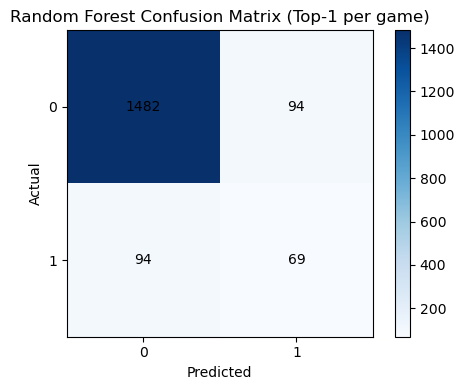

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Evaluate with the same top-1-per-game prediction logic used in metrics_df.
y_pred_top1_for_cm = pd.Series(0, index=scored_df.index, dtype=int)
y_pred_top1_for_cm.loc[winner_idx] = 1

print("Confusion Matrix (Top-1 per game):")
cm = confusion_matrix(y_test, y_pred_top1_for_cm)
print(cm)

try:
    import seaborn as sns

    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title("Random Forest Confusion Matrix (Top-1 per game)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
except ModuleNotFoundError:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Random Forest Confusion Matrix (Top-1 per game)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

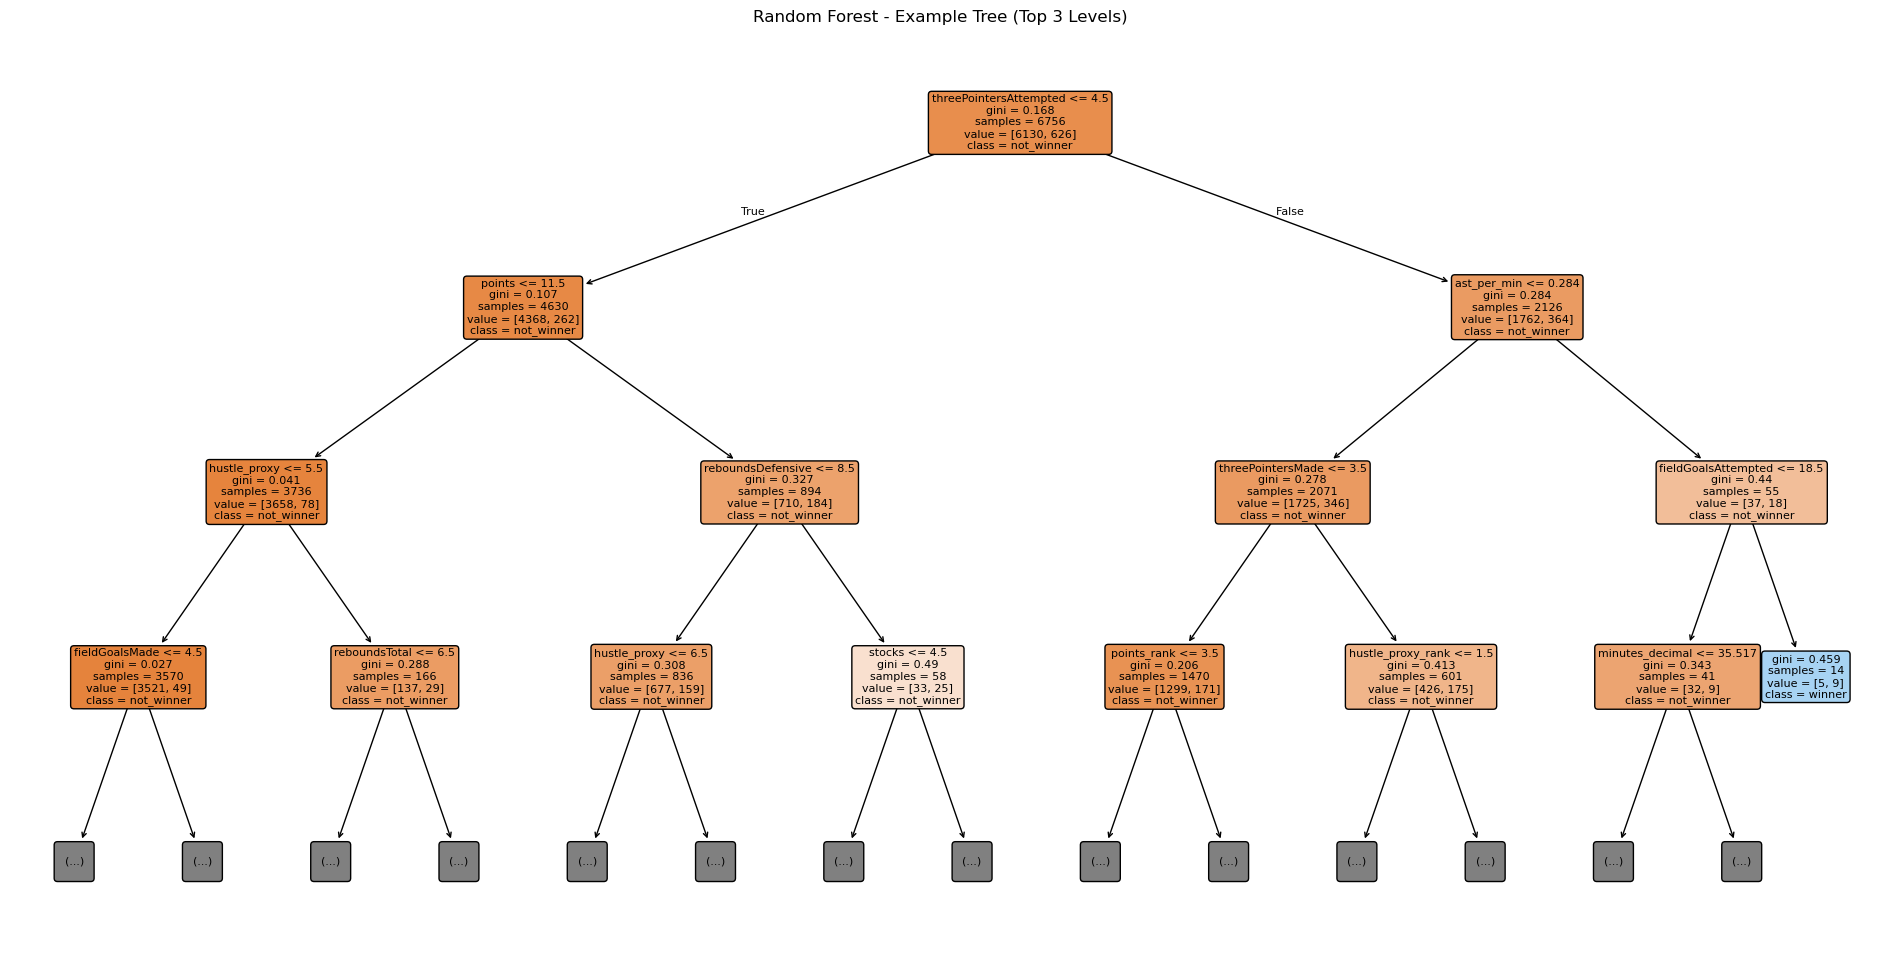

In [7]:
from sklearn import tree
import matplotlib.pyplot as plt

# Visualize one tree from the random forest (first estimator).
# Limiting depth keeps the plot readable.
one_tree = model.estimators_[0]

plt.figure(figsize=(24, 12))
tree.plot_tree(
    one_tree,
    feature_names=numeric_feature_cols,
    class_names=["not_winner", "winner"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title("Random Forest - Example Tree (Top 3 Levels)")
plt.show()

## Predict Tommy Award Winners for Other NBA Teams

Apply the trained `model` (fit on Celtics games) to predict the player most likely to be the "Tommy Award" (team-player-of-the-game) winner for each of another team's games. Starting with the **New York Knicks**.

The pipeline pulls live data from `nba_api`, mirrors the same feature engineering used to train the model (per-minute stats, hustle proxy, per-game ranks, etc.), then takes the top-1 predicted probability per game as that game's predicted winner.

In [10]:
import sys
import subprocess

try:
    import nba_api
except ModuleNotFoundError:
    print("Installing nba_api into the current kernel's Python...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "nba_api"])
    import nba_api

print(f"Using Python: {sys.executable}")
print(f"nba_api version: {nba_api.__version__ if hasattr(nba_api, '__version__') else 'unknown'}")

Using Python: /Users/teddytaussig/anaconda3/envs/COM328/bin/python
nba_api version: 1.11.4


In [12]:
import sys
import time
from pathlib import Path

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from csv_builders.build_tommy_award_player_game_table import (
    add_player_name_key,
    filter_team_players,
    get_date_column,
    get_game_id_column,
    get_team_id,
    get_team_schedule,
    get_traditional_player_box,
)
from csv_builders.enrich_player_game_with_hustle import (
    fetch_advanced_for_game,
    fetch_hustle_for_game,
)

from nba_api.stats.static import teams as nba_static_teams

TARGET_SEASONS = ["2024-25", "2025-26"]
SEASON_TYPES = ["Regular Season"]

EXCLUDE_TEAMS = {"Boston Celtics"}

ALL_NBA_TEAMS = sorted(t["full_name"] for t in nba_static_teams.get_teams())
TARGET_TEAMS = [name for name in ALL_NBA_TEAMS if name not in EXCLUDE_TEAMS]


def slugify_team(name: str) -> str:
    return name.lower().replace(" ", "_").replace(".", "")


team_configs = [
    {"name": name, "id": get_team_id(name), "slug": slugify_team(name)}
    for name in TARGET_TEAMS
]

ANALYSIS_TEAM_NAME = "New York Knicks"
TARGET_TEAM_NAME = ANALYSIS_TEAM_NAME
TARGET_TEAM_ID = get_team_id(ANALYSIS_TEAM_NAME)
team_slug = slugify_team(ANALYSIS_TEAM_NAME)

predictions_dir = Path("predictions")
predictions_dir.mkdir(parents=True, exist_ok=True)

print(f"Teams to score: {[c['name'] for c in team_configs]}")
print(f"Seasons: {TARGET_SEASONS}, types: {SEASON_TYPES}")
print(f"SHAP analysis focus team: {ANALYSIS_TEAM_NAME}")

Teams to score: ['Atlanta Hawks', 'Brooklyn Nets', 'Charlotte Hornets', 'Chicago Bulls', 'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets', 'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers', 'Los Angeles Clippers', 'Los Angeles Lakers', 'Memphis Grizzlies', 'Miami Heat', 'Milwaukee Bucks', 'Minnesota Timberwolves', 'New Orleans Pelicans', 'New York Knicks', 'Oklahoma City Thunder', 'Orlando Magic', 'Philadelphia 76ers', 'Phoenix Suns', 'Portland Trail Blazers', 'Sacramento Kings', 'San Antonio Spurs', 'Toronto Raptors', 'Utah Jazz', 'Washington Wizards']
Seasons: ['2024-25', '2025-26'], types: ['Regular Season']
SHAP analysis focus team: New York Knicks


In [13]:
def fetch_team_schedule(team_id: int, season: str, season_types: list[str]) -> pd.DataFrame:
    frames = []
    for season_type in season_types:
        sched = get_team_schedule(team_id=team_id, season=season, season_type=season_type)
        sched["SEASON_TYPE"] = season_type
        frames.append(sched)

    schedule_df = pd.concat(frames, ignore_index=True)
    sched_game_col = get_game_id_column(schedule_df)
    sched_date_col = get_date_column(schedule_df)
    schedule_df["GAME_ID"] = schedule_df[sched_game_col].astype(str).str.zfill(10)
    schedule_df["game_date"] = pd.to_datetime(schedule_df[sched_date_col]).dt.normalize()
    schedule_df = (
        schedule_df.drop_duplicates(subset=["GAME_ID"])
        .sort_values("game_date")
        .reset_index(drop=True)
    )
    return schedule_df


print("fetch_team_schedule defined. Execution is handled in the team-loop cell below.")

fetch_team_schedule defined. Execution is handled in the team-loop cell below.


In [14]:
def fetch_player_game_raw(team_id, team_slug, season, schedule, cache_dir):
    """Fetch box score + hustle + advanced for each team game.

    Uses the enriched file as a cache - if it exists, skip the API pull entirely
    and return an empty DataFrame (cell 12 will load directly from the enriched CSV).
    """
    enriched_path = cache_dir / f"{team_slug}_{season}_player_game_enriched.csv"
    if enriched_path.exists():
        print(f"[{season}] Enriched cache exists at {enriched_path}; skipping API fetch.")
        return pd.DataFrame()

    box_frames = []
    hustle_frames = []
    advanced_frames = []
    total_games = len(schedule)

    for i, row in schedule.iterrows():
        gid = str(row["GAME_ID"])
        try:
            trad = get_traditional_player_box(gid)
            trad = filter_team_players(trad, team_id=team_id)
            trad = add_player_name_key(trad)
            trad["GAME_ID"] = gid
            trad["game_date"] = row["game_date"]
            box_frames.append(trad)
        except Exception as e:
            print(f"[{season}][{gid}] traditional box failed: {e}")
            continue

        hustle_frames.append(fetch_hustle_for_game(gid))
        advanced_frames.append(fetch_advanced_for_game(gid))

        if (i + 1) % 10 == 0 or (i + 1) == total_games:
            print(f"[{season}] Processed {i + 1}/{total_games} games")
        time.sleep(0.25)

    if not box_frames:
        print(f"[{season}] No games successfully fetched.")
        return pd.DataFrame()

    players_df = pd.concat(box_frames, ignore_index=True)
    players_df["personId"] = players_df["personId"].astype(str)

    hustle_df = pd.concat(hustle_frames, ignore_index=True) if hustle_frames else pd.DataFrame()
    if not hustle_df.empty:
        hustle_df = hustle_df.drop_duplicates(subset=["GAME_ID", "personId"])
        hustle_df["personId"] = hustle_df["personId"].astype(str)

    advanced_df = pd.concat(advanced_frames, ignore_index=True) if advanced_frames else pd.DataFrame()
    if not advanced_df.empty:
        advanced_df = advanced_df.drop_duplicates(subset=["GAME_ID", "personId"])
        advanced_df["personId"] = advanced_df["personId"].astype(str)

    combined = players_df.copy()
    if not hustle_df.empty:
        combined = combined.merge(hustle_df, on=["GAME_ID", "personId"], how="left")
    else:
        combined["deflections"] = np.nan
        combined["charges_drawn"] = np.nan

    if not advanced_df.empty:
        combined = combined.merge(advanced_df, on=["GAME_ID", "personId"], how="left")
    else:
        combined["usage_rate"] = np.nan

    return combined


print("fetch_player_game_raw defined. Execution is handled in the team-loop cell below.")


fetch_player_game_raw defined. Execution is handled in the team-loop cell below.


In [15]:
def _minutes_to_decimal(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).strip()
    if not s:
        return np.nan
    if ":" in s:
        parts = s.split(":")
        try:
            mins_part = float(parts[0])
            secs_part = float(parts[1]) if len(parts) > 1 else 0.0
            return mins_part + secs_part / 60.0
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


CELTICS_COLUMN_ORDER = [
    "gameId", "teamId", "teamCity", "teamName", "teamTricode", "teamSlug",
    "personId", "firstName", "familyName", "nameI", "playerSlug", "position",
    "comment", "jerseyNum", "minutes", "minutes_decimal",
    "fieldGoalsMade", "fieldGoalsAttempted", "fieldGoalsPercentage",
    "threePointersMade", "threePointersAttempted", "threePointersPercentage",
    "freeThrowsMade", "freeThrowsAttempted", "freeThrowsPercentage",
    "reboundsOffensive", "reboundsDefensive", "reboundsTotal",
    "assists", "steals", "blocks", "turnovers", "foulsPersonal",
    "points", "plusMinusPoints",
    "GAME_ID", "player_name", "player_name_key", "y", "winner_names", "game_date",
    "stocks", "points_per_min", "oreb_per_min", "reb_per_min", "ast_per_min",
    "hustle_proxy",
    "points_rank", "reboundsOffensive_rank", "reboundsTotal_rank",
    "assists_rank", "steals_rank", "blocks_rank",
    "plusMinusPoints_rank", "minutes_decimal_rank",
    "deflections", "deflections_missing",
    "charges_drawn", "charges_drawn_missing",
    "usage_rate",
]

EXTRA_FEATURE_COLS = [
    "net_rating", "impact_efficiency", "role_outperformance",
    "stocks_per_min", "stocks_rank", "hustle_proxy_rank",
]


def build_and_score_team_season(raw_df, season, team_name, team_slug, cache_dir, model, numeric_feature_cols, X_train):
    enriched_path = cache_dir / f"{team_slug}_{season}_player_game_enriched.csv"

    if raw_df.empty and enriched_path.exists():
        print(f"[{season}] Loading scored rows from cached enriched file {enriched_path}")
        return pd.read_csv(enriched_path, dtype={"GAME_ID": str, "personId": str})

    if raw_df.empty:
        print(f"[{season}] No raw data and no enriched cache - skipping.")
        return pd.DataFrame()

    team_df = raw_df.copy()

    if "minutes_decimal" not in team_df.columns or team_df["minutes_decimal"].isna().all():
        mins_source = team_df["minutes"] if "minutes" in team_df.columns else team_df.get("MIN")
        team_df["minutes_decimal"] = mins_source.map(_minutes_to_decimal)
    else:
        team_df["minutes_decimal"] = pd.to_numeric(team_df["minutes_decimal"], errors="coerce")
        missing_mask = team_df["minutes_decimal"].isna()
        if missing_mask.any() and "minutes" in team_df.columns:
            team_df.loc[missing_mask, "minutes_decimal"] = team_df.loc[missing_mask, "minutes"].map(_minutes_to_decimal)

    team_df = team_df[team_df["minutes_decimal"] > 0].copy()

    numeric_source_cols = [
        "points", "reboundsOffensive", "reboundsDefensive", "reboundsTotal",
        "assists", "steals", "blocks", "turnovers", "foulsPersonal",
        "plusMinusPoints", "fieldGoalsMade", "fieldGoalsAttempted",
        "threePointersMade", "threePointersAttempted",
        "freeThrowsMade", "freeThrowsAttempted",
        "deflections", "charges_drawn", "usage_rate",
    ]
    for col in numeric_source_cols:
        if col not in team_df.columns:
            team_df[col] = np.nan
        team_df[col] = pd.to_numeric(team_df[col], errors="coerce")

    mins = team_df["minutes_decimal"].clip(lower=1e-6)

    team_df["stocks"] = team_df["steals"].fillna(0) + team_df["blocks"].fillna(0)
    team_df["points_per_min"] = team_df["points"] / mins
    team_df["oreb_per_min"] = team_df["reboundsOffensive"] / mins
    team_df["reb_per_min"] = team_df["reboundsTotal"] / mins
    team_df["ast_per_min"] = team_df["assists"] / mins
    team_df["stocks_per_min"] = team_df["stocks"] / mins
    team_df["hustle_proxy"] = (
        team_df["reboundsOffensive"].fillna(0)
        + team_df["steals"].fillna(0)
        + team_df["blocks"].fillna(0)
    ) / mins

    team_df["net_rating"] = team_df["plusMinusPoints"]
    eps = 1e-6
    team_df["impact_efficiency"] = team_df["net_rating"] / (team_df["usage_rate"] + eps)
    team_df["role_outperformance"] = team_df["net_rating"] * (1 - team_df["usage_rate"])

    team_df["deflections_missing"] = team_df["deflections"].isna().astype(int)
    team_df["charges_drawn_missing"] = team_df["charges_drawn"].isna().astype(int)

    rank_sources = {
        "points_rank": "points",
        "reboundsOffensive_rank": "reboundsOffensive",
        "reboundsTotal_rank": "reboundsTotal",
        "assists_rank": "assists",
        "steals_rank": "steals",
        "blocks_rank": "blocks",
        "plusMinusPoints_rank": "plusMinusPoints",
        "minutes_decimal_rank": "minutes_decimal",
        "stocks_rank": "stocks",
        "hustle_proxy_rank": "hustle_proxy",
    }
    for rank_col, source_col in rank_sources.items():
        team_df[rank_col] = team_df.groupby("GAME_ID")[source_col].rank(method="min", ascending=False)

    if "y" not in team_df.columns:
        team_df["y"] = pd.NA
    if "winner_names" not in team_df.columns:
        team_df["winner_names"] = pd.NA

    missing_features = [c for c in numeric_feature_cols if c not in team_df.columns]
    if missing_features:
        raise ValueError(f"[{season}] Missing engineered features: {missing_features}")

    train_medians = X_train.median(numeric_only=True)
    X_team = team_df[numeric_feature_cols].copy().fillna(train_medians)
    team_df["pred_prob"] = model.predict_proba(X_team)[:, 1]

    for col in CELTICS_COLUMN_ORDER:
        if col not in team_df.columns:
            team_df[col] = pd.NA

    enriched_df = team_df[CELTICS_COLUMN_ORDER + EXTRA_FEATURE_COLS + ["pred_prob"]].copy()
    enriched_path = cache_dir / f"{team_slug}_{season}_player_game_enriched.csv"
    enriched_df.to_csv(enriched_path, index=False)
    print(f"[{season}] Saved enriched player-game data to {enriched_path}")
    print(f"[{season}] Scored {len(team_df)} rows across {team_df['GAME_ID'].nunique()} games")
    return team_df


print("build_and_score_team_season defined. Execution is handled in the team-loop cell below.")


build_and_score_team_season defined. Execution is handled in the team-loop cell below.


In [16]:
def summarize_season(scored_df, season, team_name):
    """In-memory per-season summary - no CSV writes.

    Per-season detail (including pred_prob) is already saved in the enriched CSV.
    We only show winners and counts for visibility, then roll everything up
    into a single combined CSV across seasons.
    """
    if scored_df.empty:
        print(f"[{season}] No scored rows - skipping.")
        return None

    winner_idx = scored_df.groupby("GAME_ID")["pred_prob"].idxmax()
    predicted_winners = (
        scored_df.loc[winner_idx]
        .sort_values("game_date")
        .reset_index(drop=True)
    )

    winner_cols = [
        "GAME_ID", "game_date", "player_name", "minutes_decimal",
        "points", "reboundsTotal", "assists", "stocks",
        "plusMinusPoints", "pred_prob",
    ]
    winner_cols = [c for c in winner_cols if c in predicted_winners.columns]

    print(f"\n[{season}] Predicted Tommy Award winner per game - {team_name}")
    display(predicted_winners[winner_cols].head(20))

    winner_counts = (
        predicted_winners.groupby("player_name")
        .size()
        .reset_index(name="predicted_wins")
        .sort_values("predicted_wins", ascending=False)
        .reset_index(drop=True)
    )
    print(f"[{season}] Season-long Tommy Award tally:")
    display(winner_counts)

    return {
        "predicted_winners": predicted_winners,
        "winner_counts": winner_counts,
    }


all_team_scored = {}
all_team_combined_counts = {}

for cfg in team_configs:
    team_name = cfg["name"]
    team_id = cfg["id"]
    team_slug_i = cfg["slug"]
    print(f"\n{'=' * 70}\nProcessing {team_name} (team_id={team_id})\n{'=' * 70}")

    schedules_by_season = {}
    for season in TARGET_SEASONS:
        sched_df = fetch_team_schedule(team_id, season, SEASON_TYPES)
        schedules_by_season[season] = sched_df
        print(f"  [{season}] schedule: {len(sched_df)} games")

    raw_by_season = {}
    for season, sched in schedules_by_season.items():
        raw_by_season[season] = fetch_player_game_raw(
            team_id, team_slug_i, season, sched, predictions_dir
        )

    scored_by_season = {}
    for season, raw_df in raw_by_season.items():
        scored_by_season[season] = build_and_score_team_season(
            raw_df=raw_df,
            season=season,
            team_name=team_name,
            team_slug=team_slug_i,
            cache_dir=predictions_dir,
            model=model,
            numeric_feature_cols=numeric_feature_cols,
            X_train=X_train,
        )
    all_team_scored[team_name] = scored_by_season

    season_summaries = {}
    for season, scored in scored_by_season.items():
        season_summaries[season] = summarize_season(
            scored_df=scored, season=season, team_name=team_name
        )

    valid_counts = [
        s["winner_counts"].assign(season=season)
        for season, s in season_summaries.items()
        if s is not None
    ]
    if valid_counts:
        combined_counts = (
            pd.concat(valid_counts, ignore_index=True)
            .pivot_table(
                index="player_name",
                columns="season",
                values="predicted_wins",
                fill_value=0,
            )
            .assign(total=lambda d: d.sum(axis=1))
            .sort_values("total", ascending=False)
        )
        combined_out = predictions_dir / f"{team_slug_i}_predicted_tommy_counts_combined.csv"
        combined_counts.to_csv(combined_out)
        all_team_combined_counts[team_name] = combined_counts
        print(f"\n[{team_name}] Combined cross-season tally saved to {combined_out}")
        display(combined_counts.head(10))

league_rows = []
for team_name, counts_df in all_team_combined_counts.items():
    top = counts_df.head(1).reset_index()
    if not top.empty:
        top.insert(0, "team", team_name)
        league_rows.append(top)

if league_rows:
    league_leaders = pd.concat(league_rows, ignore_index=True).sort_values("total", ascending=False)
    league_out = predictions_dir / "league_predicted_tommy_leaders.csv"
    league_leaders.to_csv(league_out, index=False)
    print(f"\n{'=' * 70}\nLeague-wide predicted Tommy leaders (top player per team):")
    display(league_leaders)
    print(f"Saved to {league_out}")



Processing Atlanta Hawks (team_id=1610612737)
  [2024-25] schedule: 82 games
  [2025-26] schedule: 82 games
[2024-25] Processed 10/82 games
[2024-25] Processed 20/82 games
[2024-25] Processed 30/82 games
[2024-25] Processed 40/82 games
[2024-25] Processed 50/82 games
[2024-25] Processed 60/82 games
[2024-25] Processed 70/82 games
[2024-25] Processed 80/82 games
[2024-25] Processed 82/82 games
[2025-26] Processed 10/82 games
[2025-26] Processed 20/82 games
[2025-26] Processed 30/82 games
[2025-26] Processed 40/82 games
[2025-26] Processed 50/82 games
[2025-26] Processed 60/82 games
[2025-26] Processed 70/82 games
[2025-26] Processed 80/82 games
[2025-26] Processed 82/82 games
[2024-25] Saved enriched player-game data to predictions/atlanta_hawks_2024-25_player_game_enriched.csv
[2024-25] Scored 808 rows across 82 games
[2025-26] Saved enriched player-game data to predictions/atlanta_hawks_2025-26_player_game_enriched.csv
[2025-26] Scored 858 rows across 82 games

[2024-25] Predicted To

,GAME_ID,game_date,player_name,minutes_decimal,points,reboundsTotal,assists,stocks,plusMinusPoints,pred_prob
0,0022400064,2024-10-23,Trae Young,36.683333,30,5,12,2,12.0,0.550045
1,0022400079,2024-10-25,Trae Young,41.483333,38,8,10,4,9.0,0.460550
2,0022400100,2024-10-27,Garrison Mathews,21.616667,14,2,2,2,-1.0,0.295107
3,0022400103,2024-10-28,Jalen Johnson,38.800000,29,12,7,2,8.0,0.339850
4,0022400121,2024-10-30,Trae Young,40.350000,35,4,15,2,-16.0,0.573764
5,0022400135,2024-11-01,Garrison Mathews,29.600000,23,1,2,3,3.0,0.350076
6,0022400152,2024-11-03,Trae Young,31.350000,23,4,12,1,29.0,0.330010
7,0022400157,2024-11-04,Onyeka Okongwu,22.866667,18,10,0,2,-16.0,0.456585
8,0022400171,2024-11-06,Zaccharie Risacher,37.000000,33,7,3,5,14.0,0.506907
9,0022400185,2024-11-08,Trae Young,41.000000,35,2,13,2,14.0,0.515211


[2024-25] Season-long Tommy Award tally:


,player_name,predicted_wins
0,Trae Young,27
1,Onyeka Okongwu,13
2,Dyson Daniels,11
3,Jalen Johnson,6
4,Clint Capela,4
5,Zaccharie Risacher,4
6,De'Andre Hunter,4
7,Bogdan Bogdanović,3
8,Garrison Mathews,2
9,Larry Nance Jr.,2



[2025-26] Predicted Tommy Award winner per game - Atlanta Hawks


...


[Washington Wizards] Combined cross-season tally saved to predictions/washington_wizards_predicted_tommy_counts_combined.csv


season,2024-25,2025-26,total
player_name,,,
Alex Sarr,10.0,14.0,24.0
Jordan Poole,18.0,0.0,18.0
Bilal Coulibaly,8.0,6.0,14.0
Jonas Valančiūnas,13.0,0.0,13.0
Justin Champagnie,8.0,4.0,12.0
Tristan Vukcevic,4.0,6.0,10.0
Kyshawn George,2.0,7.0,9.0
Bub Carrington,2.0,7.0,9.0
Will Riley,0.0,7.0,7.0



League-wide predicted Tommy leaders (top player per team):


season,team,player_name,2024-25,2025-26,total
6,Denver Nuggets,Nikola Jokić,50.0,50.0,100.0
15,Milwaukee Bucks,Giannis Antetokounmpo,49.0,29.0,78.0
25,San Antonio Spurs,Victor Wembanyama,29.0,41.0,70.0
19,Oklahoma City Thunder,Shai Gilgeous-Alexander,33.0,34.0,67.0
7,Detroit Pistons,Jalen Duren,22.0,38.0,60.0
18,New York Knicks,Karl-Anthony Towns,31.0,26.0,57.0
9,Houston Rockets,Alperen Sengun,31.0,23.0,54.0
22,Phoenix Suns,Devin Booker,29.0,22.0,51.0
11,Los Angeles Clippers,Ivica Zubac,39.0,11.0,50.0
21,Philadelphia 76ers,Tyrese Maxey,22.0,27.0,49.0


Saved to predictions/league_predicted_tommy_leaders.csv


## League-wide: position of predicted Tommy winners
Each slice counts one **model-predicted** winner per **team** per **game** (`argmax` of `pred_prob` within `GAME_ID`), using all `predictions/*_player_game_enriched.csv` files. **Rows with missing `position` are excluded** from the chart (see printed counts).

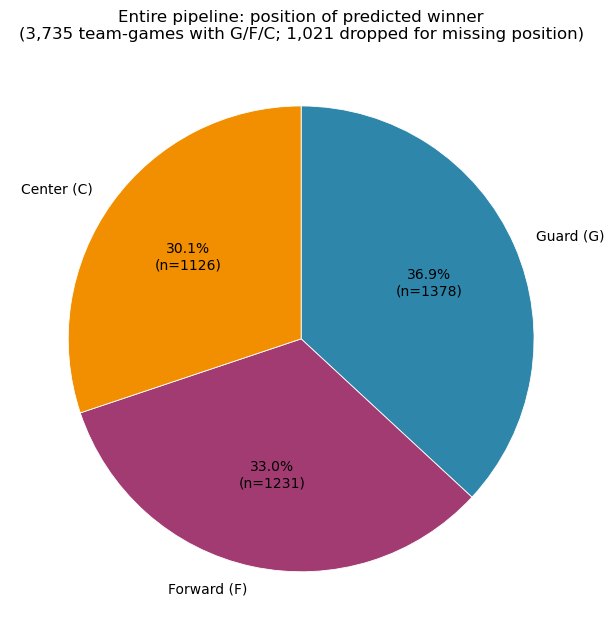

Counts (G/F/C only): {'G': 1378, 'F': 1231, 'C': 1126}
Excluded missing position: 1021 of 4756 team-games (21.5%)


In [3]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# One top-1 predicted winner per team-game from every saved enriched CSV (same scope as the league loop).
PRED = Path("predictions")
ENRICHED_RE = re.compile(r"^(.+)_(20\d{2}-\d{2})_player_game_enriched\.csv$")

frames: list[pd.DataFrame] = []
for f in sorted(PRED.glob("*_player_game_enriched.csv")):
    if not ENRICHED_RE.match(f.name):
        continue
    df = pd.read_csv(f, dtype={"GAME_ID": str, "personId": str}, low_memory=False)
    if "pred_prob" not in df.columns or "GAME_ID" not in df.columns:
        continue
    idx = df.groupby("GAME_ID", sort=False)["pred_prob"].idxmax()
    frames.append(df.loc[idx, ["position"]])

if not frames:
    raise FileNotFoundError(
        "No predictions/*_player_game_enriched.csv with pred_prob. "
        "Run the cell that fetches/scores all teams (writes enriched files) first."
    )

pos_all = pd.concat(frames, ignore_index=True)["position"]
n_total = len(pos_all)
pos = pos_all.dropna()
n_dropped = n_total - len(pos)
if pos.empty:
    raise ValueError("All rows have missing position — cannot build pie chart.")
counts = pos.value_counts()
order = [x for x in ("G", "F", "C") if x in counts.index]
order += [x for x in counts.index if x not in order]
sizes = np.array([counts[k] for k in order], dtype=float)

pretty = {"G": "Guard (G)", "F": "Forward (F)", "C": "Center (C)"}
label_list = [pretty.get(k, k) for k in order]
colors = {"G": "#2E86AB", "F": "#A23B72", "C": "#F18F01"}
c_list = [colors.get(k, "#64748B") for k in order]

def _autopct(arr: np.ndarray):
    def _p(pct: float) -> str:
        n = int(round(pct / 100.0 * float(arr.sum())))
        return f"{pct:.1f}%\n(n={n})"

    return _p

display(
    Markdown(
        "## League-wide: position of predicted Tommy winners\n"
        "Each slice counts one **model-predicted** winner per **team** per **game** "
        "(`argmax` of `pred_prob` within `GAME_ID`), using all `predictions/*_player_game_enriched.csv` files. "
        "**Rows with missing `position` are excluded** from the chart (see printed counts)."
    )
)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(
    sizes,
    labels=label_list,
    colors=c_list,
    startangle=90,
    counterclock=False,
    autopct=_autopct(sizes),
    wedgeprops={"edgecolor": "white", "linewidth": 0.6},
)
ax.set_title(
    f"Entire pipeline: position of predicted winner\n"
    f"({int(sizes.sum()):,} team-games with G/F/C; {n_dropped:,} dropped for missing position)"
)
fig.tight_layout()
plt.show()
print("Counts (G/F/C only):", counts.reindex(order).to_dict())
print(f"Excluded missing position: {n_dropped} of {n_total} team-games ({100 * n_dropped / n_total:.1f}%)")

## Why did a particular player win the most predicted Tommy Awards?

Use SHAP values on the trained Random Forest to see which features pushed a player's predicted probability up on the nights they were predicted winners. For a random forest, SHAP's `TreeExplainer` gives an exact per-row, per-feature contribution to the predicted probability, which is the principled way to answer "what was the most informative statistic?".

Default is Karl-Anthony Towns; change `FOCUS_PLAYER` to analyze anyone else.

In [17]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import shap
except ModuleNotFoundError:
    print("Installing shap into current kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "shap"])
    import shap

FOCUS_PLAYER = "Karl-Anthony Towns"
TOP_N_FEATURES = 15

enriched_frames = []
for season in TARGET_SEASONS:
    path = predictions_dir / f"{team_slug}_{season}_player_game_enriched.csv"
    if path.exists():
        season_df = pd.read_csv(path, dtype={"GAME_ID": str, "personId": str})
        season_df["season"] = season
        enriched_frames.append(season_df)

if not enriched_frames:
    raise FileNotFoundError("No enriched CSVs found - run cells 8-13 first.")

all_enriched = pd.concat(enriched_frames, ignore_index=True)
per_game_rank = all_enriched.groupby(["season", "GAME_ID"])["pred_prob"].rank(method="min", ascending=False)
winner_rows = all_enriched[per_game_rank == 1].copy()

print(f"{TARGET_TEAM_NAME} predicted Tommy winners: {len(winner_rows)} games across {len(TARGET_SEASONS)} seasons")
display(
    winner_rows.groupby("player_name").size()
    .reset_index(name="predicted_wins")
    .sort_values("predicted_wins", ascending=False)
    .reset_index(drop=True)
)


New York Knicks predicted Tommy winners: 164 games across 2 seasons


,player_name,predicted_wins
0,Karl-Anthony Towns,57
1,Jalen Brunson,39
2,Josh Hart,13
3,Miles McBride,12
4,OG Anunoby,11
5,Mikal Bridges,11
6,Mitchell Robinson,8
7,Landry Shamet,4
8,Cameron Payne,2
9,Jordan Clarkson,2


In [18]:
from __future__ import annotations

import numpy as np
import pandas as pd
import shap
from IPython.display import display

explainer = shap.TreeExplainer(model)
train_medians = X_train.median(numeric_only=True)

X_winners = winner_rows[numeric_feature_cols].copy().fillna(train_medians)
shap_raw = explainer.shap_values(X_winners, check_additivity=False)

if isinstance(shap_raw, list):
    shap_winner = shap_raw[1]
elif hasattr(shap_raw, "ndim") and shap_raw.ndim == 3:
    shap_winner = shap_raw[..., 1]
else:
    shap_winner = shap_raw

shap_winner_df = pd.DataFrame(shap_winner, columns=numeric_feature_cols, index=X_winners.index)

team_feature_importance = pd.DataFrame({
    "feature": numeric_feature_cols,
    "mean_shap": shap_winner_df.mean(axis=0).values,
    "mean_abs_shap": shap_winner_df.abs().mean(axis=0).values,
    "winner_mean_value": X_winners.mean(axis=0).values,
    "train_median": train_medians.reindex(numeric_feature_cols).values,
})

print(f"=== {TARGET_TEAM_NAME}: MOST IMPORTANT features driving Tommy Award picks ===")
print(f"(Computed across all {len(winner_rows)} predicted-winner rows over {len(TARGET_SEASONS)} seasons)")

print("\nSorted by mean |SHAP| - features the model relies on MOST when picking Knicks winners:")
display(
    team_feature_importance.sort_values("mean_abs_shap", ascending=False)
    .head(TOP_N_FEATURES)
    .reset_index(drop=True)
)

print("\nSorted by mean SHAP (signed) - features that most consistently push probability toward Tommy winner:")
display(
    team_feature_importance.sort_values("mean_shap", ascending=False)
    .head(TOP_N_FEATURES)
    .reset_index(drop=True)
)

=== New York Knicks: MOST IMPORTANT features driving Tommy Award picks ===
(Computed across all 164 predicted-winner rows over 2 seasons)

Sorted by mean |SHAP| - features the model relies on MOST when picking Knicks winners:


,feature,mean_shap,mean_abs_shap,winner_mean_value,train_median
0,points,0.052103,0.053216,24.829268,8.000000
1,fieldGoalsMade,0.048265,0.049170,8.926829,3.000000
2,points_per_min,0.040283,0.044846,0.758956,0.391400
3,points_rank,0.032451,0.035081,1.963415,6.000000
4,reb_per_min,0.016570,0.017979,0.262163,0.167500
5,reboundsTotal,0.015952,0.016828,8.426829,4.000000
6,plusMinusPoints_rank,0.006234,0.014537,4.256098,6.000000
7,threePointersMade,0.009030,0.013038,2.621951,1.000000
8,usage_rate,0.002268,0.012319,0.002534,0.001820
9,fieldGoalsAttempted,0.004424,0.009971,15.871951,7.000000



Sorted by mean SHAP (signed) - features that most consistently push probability toward Tommy winner:


,feature,mean_shap,mean_abs_shap,winner_mean_value,train_median
0,points,0.052103,0.053216,24.829268,8.000000
1,fieldGoalsMade,0.048265,0.049170,8.926829,3.000000
2,points_per_min,0.040283,0.044846,0.758956,0.391400
3,points_rank,0.032451,0.035081,1.963415,6.000000
4,reb_per_min,0.016570,0.017979,0.262163,0.167500
5,reboundsTotal,0.015952,0.016828,8.426829,4.000000
6,threePointersMade,0.009030,0.013038,2.621951,1.000000
7,reboundsOffensive,0.007444,0.008379,2.317073,1.000000
8,assists,0.007304,0.009736,4.341463,2.000000
9,minutes_decimal,0.007177,0.007738,33.154268,23.516667


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

top_abs = (
    team_feature_importance.sort_values("mean_abs_shap", ascending=False)
    .head(TOP_N_FEATURES)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, max(4.5, 0.4 * len(top_abs))))
colors = ["#1f77b4" if v >= 0 else "#d62728" for v in top_abs["mean_shap"]]
ax.barh(top_abs["feature"][::-1], top_abs["mean_shap"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean SHAP value on predicted-winner rows (positive = toward Tommy winner)")
ax.set_title(f"Most informative features for {TARGET_TEAM_NAME} Tommy Award predictions\n(across {len(winner_rows)} predicted winners, seasons {', '.join(TARGET_SEASONS)})")
plt.tight_layout()
plt.show()

print(f"=== Focused breakdown for {FOCUS_PLAYER} ===")
focus_mask = winner_rows["player_name"].str.strip().str.lower() == FOCUS_PLAYER.strip().lower()
if not focus_mask.any():
    print(f"{FOCUS_PLAYER} has no predicted wins - skipping per-player breakdown.")
else:
    focus_idx = winner_rows.index[focus_mask]
    focus_shap = shap_winner_df.loc[focus_idx]
    focus_X = X_winners.loc[focus_idx]

    focus_summary = pd.DataFrame({
        "feature": numeric_feature_cols,
        "mean_shap_for_focus": focus_shap.mean(axis=0).values,
        "mean_abs_shap_for_focus": focus_shap.abs().mean(axis=0).values,
        "focus_mean_value": focus_X.mean(axis=0).values,
        "train_median": train_medians.reindex(numeric_feature_cols).values,
    }).sort_values("mean_shap_for_focus", ascending=False).reset_index(drop=True)

    print(f"\nTop features pushing {FOCUS_PLAYER}'s predicted probability UP across his {len(focus_idx)} wins:")
    display(focus_summary.head(TOP_N_FEATURES))

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.4 * TOP_N_FEATURES)))
    focus_top = focus_summary.head(TOP_N_FEATURES)
    colors_f = ["#2ca02c" if v >= 0 else "#d62728" for v in focus_top["mean_shap_for_focus"]]
    ax.barh(focus_top["feature"][::-1], focus_top["mean_shap_for_focus"][::-1], color=colors_f[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Mean SHAP value")
    ax.set_title(f"Why the model picked {FOCUS_PLAYER} as {TARGET_TEAM_NAME} Tommy winner\n(avg across {len(focus_idx)} games)")
    plt.tight_layout()
    plt.show()

NameError: name 'team_feature_importance' is not defined